## Importing my necessary libraries used to train and test the model 

In [1]:
import json 
import pickle 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import tensorflow as tf 

tf.random.set_seed(42)
np.random.seed(42)

## Seperating my data into training set, testing set and validation set 

In [2]:
#Assigning data to various variable names 
train_df = pd.read_csv('malaria_train.csv')
val_df = pd.read_csv('malaria_val.csv')
test_df = pd.read_csv('malaria_test.csv')

#Separting the training dataset into target and features  
X_train = train_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_train = train_df['Malaria_Positive'].values.astype(np.float32)

#Seperating the raw dataset into target and features 
X_val = val_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_val = val_df['Malaria_Positive'].values.astype(np.float32)

#Seperating the testing dataset into target and features 
X_test = test_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_test = test_df['Malaria_Positive'].values.astype(np.float32)

#Printing the shape of my training, testing and raw sets as well as number of features
print(f'Train: {X_train.shape}')
print(f'Raw: {X_val.shape}')
print(f'Test: {X_test.shape}')

Train: (560, 15)
Raw: (120, 15)
Test: (120, 15)


In [3]:
import tensorflow as tf
from tensorflow import keras

from tensorflow import keras
import tensorflow as tf

In [4]:
from tensorflow import keras
def build_ann(n_features):
    input_layer = keras.Input(shape=(n_features,), name='features')

    #Block 1
    X = keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(input_layer)
    X = keras.layers.BatchNormalization()(X)
    X = keras.layers.Activation('relu')(X)
    X = keras.layers.Dropout(0.3)(X)

    #Block 2
    X = keras.layers.Dense(32)(X)
    X = keras.layers.BatchNormalization()(X)
    X = keras.layers.Activation('relu')(X)
    X = keras.layers.Dropout(0.3)(X)

    #Block 3
    X = keras.layers.Dense(32)(X)
    X = keras.layers.Activation('relu')(X)
    X = keras.layers.Dropout(0.2)(X)

    #output a single probability
    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(X)
    return keras.Model(inputs=input_layer, outputs=outputs, name='MalariaANN')

print(X_train.shape)
print(X_train.ndim)
print(X_train.dtype)


(560, 15)
2
float32


In [76]:
W = tf.constant([[1,2,3,4],[5,6,7,8],[9,-1,-2,-3]], dtype=tf.float32)
X_input = tf.constant([[1],[2],[3]], dtype=tf.float32)
B = tf.constant([[1],[2],[3],[4]], dtype=tf.float32)
print(f'the weight matrix shape: {W.shape}')
print(f'the input matrix shape: {X_input.shape}')
print(f'the bias shape: {B.shape}')

# Z = tf.matmul(W,X_input + B) #computing throws an error due to shape incompatability 
WT = tf.transpose(W)
BT = tf.transpose(B)
print(f'the transpose shape is : {WT.shape}')
print(f'the bias transpose shape is: {BT.shape}')
z = tf.matmul(WT, X_input + BT)
print(z)



the weight matrix shape: (3, 4)
the input matrix shape: (3, 1)
the bias shape: (4, 1)
the transpose shape is : (4, 3)
the bias transpose shape is: (1, 4)
tf.Tensor(
[[53. 68. 83. 98.]
 [18. 25. 32. 39.]
 [19. 27. 35. 43.]
 [20. 29. 38. 47.]], shape=(4, 4), dtype=float32)


In [104]:
model = build_ann(X_train.shape[1])
model.summary()

# 
# value.OVERLOADABLE

Model: "MalariaANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Dense)                    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,905 (30.88 KB)

 Trainable params: 7,585 (29.63 KB)

 Non-trainable params: 320 (1.25 KB)

Compiling the model

In [105]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-5),
    loss = 'binary_crossentropy',
    metrics = [
        'accuracy',
        keras.metrics.AUC(name='Auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [106]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_Auc',patience=25,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_Auc',factor=0.5,patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_malaria.keras', monitor='val_Auc',
        save_best_only=True, mode='max', verbose=0
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=300, batch_size=12,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)
print(f'\nepochs run: {len(history.history['loss'])}')
print(f'\nBest val AUC: {max(history.history['val_Auc']):.4f}')

Epoch 1/300


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - Auc: 0.6570 - accuracy: 0.5696 - loss: 0.6852 - precision: 0.4886 - recall: 0.7339 - val_Auc: 0.7809 - val_accuracy: 0.6417 - val_loss: 0.6681 - val_precision: 0.5422 - val_recall: 0.9000 - learning_rate: 5.0000e-05
Epoch 2/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - Auc: 0.6905 - accuracy: 0.6143 - loss: 0.6683 - precision: 0.5258 - recall: 0.7425 - val_Auc: 0.8291 - val_accuracy: 0.6833 - val_loss: 0.6470 - val_precision: 0.5714 - val_recall: 0.9600 - learning_rate: 5.0000e-05
Epoch 3/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - Auc: 0.7137 - accuracy: 0.6339 - loss: 0.6308 - precision: 0.5473 - recall: 0.6953 - val_Auc: 0.8696 - val_accuracy: 0.7750 - val_loss: 0.6218 - val_precision: 0.6533 - val_recall: 0.9800 - learning_rate: 5.0000e-05
Epoch 4/300
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - Auc: 0.7456 - accuracy: 0.6786 - loss: 0.6105 - precision: 0.5898 - recall: 0.7468 - val_Auc: 0.9020 - val_accuracy: 0.7833 - val_loss: 0.5936 - va

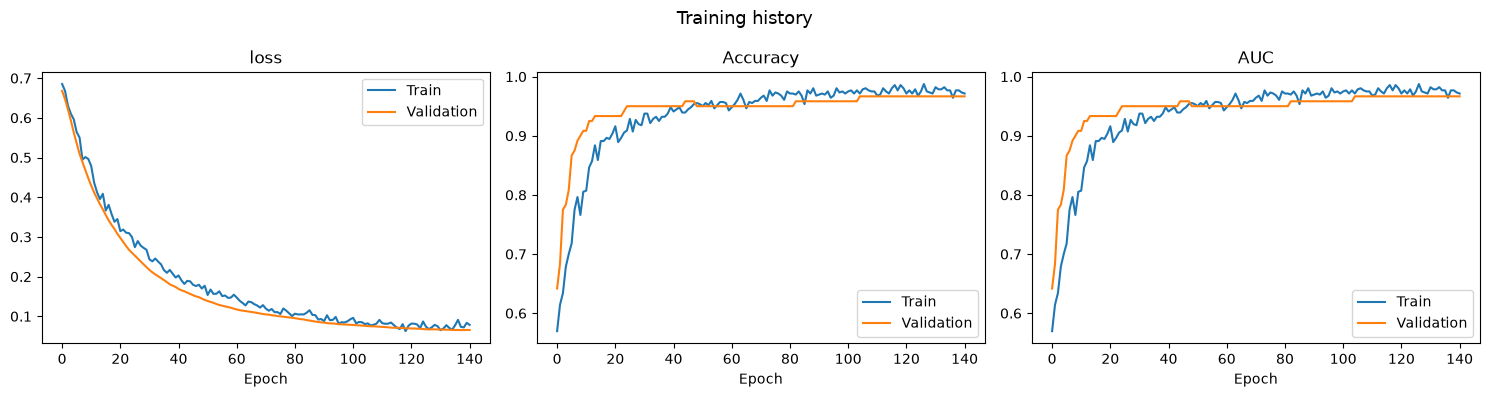

In [107]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(1,3, figsize=(15,4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['accuracy'], label='Train')
axes[2].plot(history.history['val_accuracy'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training history',fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [108]:
model.load_weights('best_malaria.keras')

test_results = model.evaluate(X_test, y_test, verbose=0)
for name,value in zip(model.metrics_names, test_results):
    print(f'{name:<12}: {value:.4f}')

loss        : 0.0296
compile_metrics: 0.9917


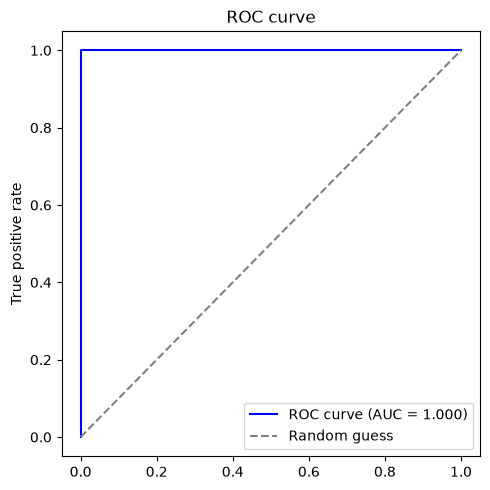

ROc-AUC: 1.0000


In [109]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,5))
plt.plot(fpr,tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random guess')
# plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROc-AUC: {auc_score:.4f}')

              precision    recall  f1-score   support

  No Malaria       0.99      1.00      0.99        70
     Malaria       1.00      0.98      0.99        50

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



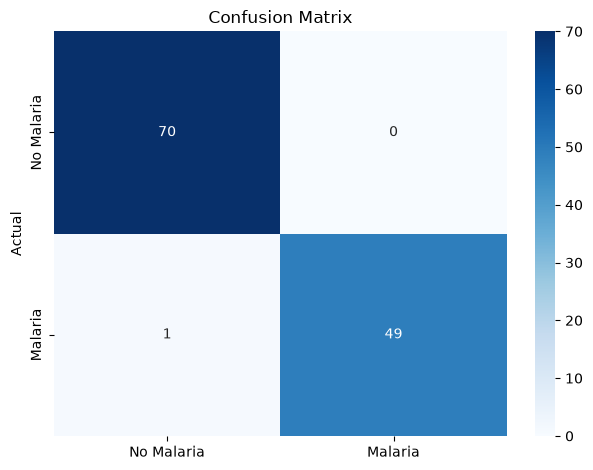

In [110]:
y_pred = (y_prob >= 0.5).astype(int)
import seaborn as sns
print(classification_report(y_test, y_pred, target_names=['No Malaria', 'Malaria']))

cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Malaria', 'Malaria'],
            yticklabels=['No Malaria', 'Malaria'])

plt.ylabel('Actual')
plt.xlabel=('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()